<a href="https://colab.research.google.com/github/D2718281828nis/BioMedAI-sEEG-core-of-epilepsy/blob/main/sEEG_temporal_wavelet_graph_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal sEEG graph from an EDF file (Google Colab)

This notebook loads `dataset/sEEG-HFOs-8.edf`, removes marker channels named `MKR<i>` (for example, `MKR1`), splits every retained sEEG channel into consecutive **2-second windows**, and builds one sparse NetworkX graph per window.

- **Nodes:** channels, with `db4` discrete-wavelet energy and signal-statistic features.
- **Edges:** signed correlations between multiscale `db4` coefficient vectors. Weak correlations are removed, and per-node top-*k* pruning prevents dense graphs.
- **Temporal output:** dense node-feature tensors plus sparse edge tensors, saved with PyTorch.
- **EDF-annotated event:** the file's own embedded EDF+ annotation channel marks `приступ + БТКП` ("seizure + bilateral tonic-clonic seizure") at 10396.445 s — decoded with the correct `cp1251` (Windows-1251 Cyrillic) codec, not typed in as an apriori guess. The 10396–10398 s window containing it, and channels `CC'4`, `CC'5`, and `CR'5`, are explicitly annotated and visualized. The annotation does not alter measured correlations.

**Data hygiene note:** after ≈10550 s this recording contains a surgical cauterization procedure, not brain activity. The load cell crops to 0–10550 s (`ANALYSIS_END_SECONDS`) before the windowed graph is built, so the whole-recording event-score percentile ("Quantify and preserve the extreme point") and the channel/event-score correlations ("Find biomarker") are computed only over brain activity — without the crop, that non-physiological segment can dominate both statistics. See [`sEEG_blind_vs_targeted_detection_colab.ipynb`](sEEG_blind_vs_targeted_detection_colab.ipynb) for why that segment matters and how it was identified.

> Google Colab is Linux-based. A path written locally as `\dataset\sEEG-HFOs-8.edf` corresponds to `/content/dataset/sEEG-HFOs-8.edf` after upload.


In [1]:
# Install analysis dependencies into the Colab runtime.
%pip install -q mne edfio PyWavelets networkx seaborn ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import mne
import networkx as nx
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
import torch
from IPython.display import display

mne.set_log_level("WARNING")
np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (14, 7), "axes.grid": False})


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Configuration

`CORRELATION_THRESHOLD` removes weak edges. `TOP_K_PER_NODE` then retains only each node's strongest candidates (the union of those selections), preserving all nodes even if a node becomes isolated. Adjust these two values if the graphs are too dense or sparse.


In [3]:
WINDOW_SECONDS = 2.0
WAVELET = "db4"
CORRELATION_THRESHOLD = 0.65
TOP_K_PER_NODE = 6
# EDF-annotated event (read from the file, not an apriori guess): the EDF+
# annotation channel marks "приступ + БТКП" ("seizure + bilateral
# tonic-clonic seizure") at 10396.445 s, decoded with the correct cp1251
# (Windows-1251 Cyrillic) codec. This is the 2-second window containing it.
KNOWN_EVENT_INTERVAL = (10396.0, 10398.0)
KNOWN_EVENT_CHANNELS = ("EEG CC'4", "EEG CC'5", "EEG CR'5")
# After ~10550 s this recording contains a surgical cauterization procedure, not brain
# activity. It is excluded from every analysis below by cropping the raw data at load
# time (next section), so the whole-recording event-score percentile and the
# channel/event-score correlations further down never see it -- both are exactly the
# kind of recording-wide statistic a large non-physiological excursion can distort.
ANALYSIS_END_SECONDS = 10550.0
OUTPUT_DIR = Path("/content") if Path("/content").is_dir() else Path.cwd() / "seeg_graph_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert WINDOW_SECONDS == KNOWN_EVENT_INTERVAL[1] - KNOWN_EVENT_INTERVAL[0]
assert ANALYSIS_END_SECONDS > KNOWN_EVENT_INTERVAL[1]
print(f"Outputs will be written to {OUTPUT_DIR}")

Outputs will be written to /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/seeg_graph_output


## Find and load the local EDF

Upload the file into a `dataset` directory from Colab's **Files** panel. If needed, uncomment the upload cell. Runtime uploads are temporary.


In [4]:
# Optional browser upload; uncomment when the dataset is not in /content/dataset.
# from google.colab import files
# uploaded = files.upload()
# Path("/content/dataset").mkdir(parents=True, exist_ok=True)
# uploaded_name = next(iter(uploaded))
# Path(uploaded_name).replace(Path("/content/dataset/sEEG-HFOs-8.edf"))


In [5]:
candidates = [
    Path("/content/sEEG-HFOs-8.edf"),
    Path("dataset/sEEG-HFOs-8.edf"),
]
edf_path = next((path for path in candidates if path.is_file()), None)
if edf_path is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "sEEG-HFOs-8.edf was not found. Upload it with the cell above. "
        f"Searched:\n{searched}"
    )

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING", encoding='latin1')

# tmin=0 keeps raw.first_samp at 0; tmax is clamped to the timestamp of the last sample,
# (n_times - 1) / sfreq -- fractionally less than n_times / sfreq, and what MNE's crop()
# actually accepts -- so ANALYSIS_END_SECONDS >= the recording's length is a no-op
# instead of a ValueError.
full_duration_s = raw.n_times / raw.info["sfreq"]
max_tmax_s = (raw.n_times - 1) / raw.info["sfreq"]
crop_end_s = min(ANALYSIS_END_SECONDS, max_tmax_s)
excluded_s = full_duration_s - crop_end_s
raw.crop(tmin=0.0, tmax=crop_end_s)

duration_s = raw.n_times / raw.info["sfreq"]
print(f"Loaded {edf_path.resolve()}")
print(f"{len(raw.ch_names)} channels, {raw.info['sfreq']:.3f} Hz, full duration {full_duration_s:.2f} s")
if excluded_s > 0:
    print(f"Excluded post-cauterization segment: {crop_end_s:.1f}-{full_duration_s:.1f} s "
          f"({excluded_s:.1f} s / {excluded_s / 60:.1f} min) -- surgical procedure, not brain activity.")
print(f"Analysis duration after crop: {duration_s:.2f} s")

/var/folders/57/nnp0s5hs27d65fbf6n2frbjh0000gn/T/ipykernel_82304/1953385644.py:13: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING", encoding='latin1')


Loaded /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/dataset/sEEG-HFOs-8.edf
102 channels, 256.000 Hz, full duration 14095.00 s
Excluded post-cauterization segment: 10550.0-14095.0 s (3545.0 s / 59.1 min) -- surgical procedure, not brain activity.
Analysis duration after crop: 10550.00 s


## Keep sEEG channels and exclude `MKR<i>` markers

The regular expression is case-insensitive and accepts optional whitespace between `MKR` and its numeric index. The channel order from the EDF is preserved.


In [6]:
marker_pattern = re.compile(r"^MKR\s*\d+\+?$", flags=re.IGNORECASE)
marker_channels = [name for name in raw.ch_names if marker_pattern.fullmatch(name.strip())]
seeg_channels = [name for name in raw.ch_names if name not in marker_channels]
if not seeg_channels:
    raise ValueError("No non-marker channels remain after excluding MKR<i> channels.")

missing_event_channels = [name for name in KNOWN_EVENT_CHANNELS if name not in seeg_channels]
channel_table = pd.DataFrame({
    "channel_index": range(len(seeg_channels)),
    "channel": seeg_channels,
    "known_annotated_event_channel": [name in KNOWN_EVENT_CHANNELS for name in seeg_channels],
})
print(f"Excluded {len(marker_channels)} marker channels: {marker_channels}")
print(f"Retained {len(seeg_channels)} channels")
if missing_event_channels:
    print("WARNING: expected event channels absent from EDF:", missing_event_channels)
display(channel_table)

Excluded 2 marker channels: ['MKR1+', 'MKR2+']
Retained 100 channels


,channel_index,channel,known_annotated_event_channel
0,0,EEG R1,False
1,1,EEG R2,False
2,2,EEG R3,False
3,3,EEG R4,False
4,4,EEG R5,False
...,...,...,...
95,95,EEG PA'4,False
96,96,EEG PA'5,False
97,97,EEG PA'6,False
98,98,EEG PA'7,False


## Bipolar montage: an alternative reference for the same graph

`build_bipolar_montage` reads the montage straight out of `seeg_channels` — no separate electrode map. `load_bipolar_window` is the bipolar counterpart of `raw.get_data(picks=seeg_channels, start=..., stop=...)`: it loads the same referential contacts once and subtracts adjacent pairs (`data[a] - data[b]`), a spatial high-pass filter that cancels whatever two neighboring contacts share (the common reference, distant volume-conducted activity) and keeps only their local gradient. The full-recording temporal graph below still analyses the referential montage — re-running the entire windowed tensor pipeline in bipolar as well would double an already expensive computation — but the known-event section further down builds and compares *both* montages' graphs for that one window, exactly analogous to `extreme_event_agent.edf_workflow.compare_montages` in the installable package.


In [7]:
def parse_contact_name(name):
    match = re.match(r"^(?:EEG\s+)?([A-Za-z]+'?)\s*(\d+)$", name.strip())
    if match is None:
        return None
    return match.group(1), int(match.group(2))


def build_bipolar_montage(names):
    shafts = {}
    for name in names:
        parsed = parse_contact_name(name)
        if parsed is None:
            continue
        shaft, contact = parsed
        shafts.setdefault(shaft, []).append((contact, name))
    montage = {}
    for shaft, contacts in shafts.items():
        contacts.sort(key=lambda item: item[0])
        montage[shaft] = [(contacts[i][1], contacts[i + 1][1]) for i in range(len(contacts) - 1)]
    return montage


bipolar_montage = build_bipolar_montage(seeg_channels)
bipolar_pairs_by_label = {}
for shaft, pairs in bipolar_montage.items():
    for name_a, name_b in pairs:
        contact_a = parse_contact_name(name_a)[1]
        contact_b = parse_contact_name(name_b)[1]
        bipolar_pairs_by_label[f"{shaft}{contact_a}-{contact_b}"] = (name_a, name_b)
bipolar_channels = list(bipolar_pairs_by_label)
print(f"Bipolar montage: {len(bipolar_montage)} shafts, {len(bipolar_channels)} pairs "
      f"(referential: {len(seeg_channels)} channels)")

# Bipolar labels containing either endpoint of a KNOWN_EVENT_CHANNELS contact,
# for highlighting -- a single referential contact can appear in up to two pairs.
bipolar_event_channels = tuple(
    label for label, (a, b) in bipolar_pairs_by_label.items()
    if a in KNOWN_EVENT_CHANNELS or b in KNOWN_EVENT_CHANNELS
)
print(f"Bipolar pairs touching a known-event contact: {bipolar_event_channels}")


def load_bipolar_window(start_sample, stop_sample):
    needed = sorted({name for pair in bipolar_pairs_by_label.values() for name in pair})
    index_of = {name: index for index, name in enumerate(needed)}
    block = raw.get_data(picks=needed, start=start_sample, stop=stop_sample) * 1e6
    return np.stack([block[index_of[a]] - block[index_of[b]]
                     for a, b in bipolar_pairs_by_label.values()])


Bipolar montage: 12 shafts, 88 pairs (referential: 100 channels)
Bipolar pairs touching a known-event contact: ("CR'4-5", "CR'5-6", "CC'3-4", "CC'4-5", "CC'5-6")


## Wavelet features and correlation graph

For each channel/window, `pywt.wavedec` produces the maximum valid decomposition (capped at level 5). Node features contain log-energy for the approximation and every detail band, followed by mean, standard deviation, RMS, and line length. All windows have the same feature width because their sample counts are fixed.

Edge correlation is computed between concatenated, independently standardized wavelet subbands. This prevents a high-energy band from dominating the correlation while retaining multiscale waveform information. The sparse graph stores both signed `correlation` and `abs_correlation`.


In [8]:
def wavelet_representation(signal, wavelet=WAVELET, max_level=5):
    signal = np.asarray(signal, dtype=np.float64)
    wavelet_obj = pywt.Wavelet(wavelet)
    valid_level = pywt.dwt_max_level(len(signal), wavelet_obj.dec_len)
    level = min(max_level, valid_level)
    if level < 1:
        raise ValueError(
            f"A {len(signal)}-sample window is too short for the {wavelet} wavelet."
        )

    coefficients = pywt.wavedec(signal, wavelet_obj, level=level, mode="symmetric")
    log_energies = [np.log1p(np.mean(np.square(band))) for band in coefficients]
    statistics = [
        np.mean(signal),
        np.std(signal),
        np.sqrt(np.mean(np.square(signal))),
        np.mean(np.abs(np.diff(signal))),
    ]
    features = np.asarray(log_energies + statistics, dtype=np.float32)

    standardized_bands = []
    for band in coefficients:
        scale = np.std(band)
        standardized_bands.append((band - np.mean(band)) / (scale + 1e-12))
    correlation_vector = np.concatenate(standardized_bands)
    return features, correlation_vector, level


def prune_correlations(correlation, threshold, top_k):
    # Return undirected (i, j, signed correlation) edges after threshold/top-k pruning.
    n_nodes = correlation.shape[0]
    magnitude = np.abs(correlation)
    np.fill_diagonal(magnitude, 0.0)
    selected = set()
    for node in range(n_nodes):
        candidates = np.flatnonzero(magnitude[node] >= threshold)
        if candidates.size:
            strongest = candidates[np.argsort(magnitude[node, candidates])[-top_k:]]
            selected.update(tuple(sorted((node, int(other)))) for other in strongest if other != node)
    return [(i, j, float(correlation[i, j])) for i, j in sorted(selected)]


def build_window_graph(window_data, channel_names, start_s):
    node_features, wavelet_vectors = [], []
    decomposition_level = None
    for signal in window_data:
        features, vector, decomposition_level = wavelet_representation(signal)
        node_features.append(features)
        wavelet_vectors.append(vector)

    node_features = np.stack(node_features)
    correlation = np.corrcoef(np.stack(wavelet_vectors))
    correlation = np.nan_to_num(correlation, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(correlation, 1.0)
    edges = prune_correlations(correlation, CORRELATION_THRESHOLD, TOP_K_PER_NODE)

    graph = nx.Graph(
        window_start_s=float(start_s),
        window_end_s=float(start_s + WINDOW_SECONDS),
        known_extreme_event=(KNOWN_EVENT_INTERVAL[0] <= start_s < KNOWN_EVENT_INTERVAL[1]),
        wavelet=WAVELET,
        wavelet_level=decomposition_level,
    )
    for index, name in enumerate(channel_names):
        graph.add_node(
            name,
            index=index,
            features=node_features[index],
            known_event_channel=name in KNOWN_EVENT_CHANNELS,
        )
    for i, j, value in edges:
        graph.add_edge(
            channel_names[i], channel_names[j],
            correlation=value,
            abs_correlation=abs(value),
        )
    return graph, node_features, correlation


## Build the temporal graph, one 2-second window at a time

Only complete, non-overlapping windows are processed. NetworkX graphs are constructed for analysis, then converted immediately to sparse edge tensors so long recordings do not require retaining thousands of Python graph objects. The first graph and the EDF-annotated event graph (10396–10398 s) are retained for visualization.


In [9]:
sfreq = float(raw.info["sfreq"])
window_samples = int(round(WINDOW_SECONDS * sfreq))
n_windows = raw.n_times // window_samples
if n_windows == 0:
    raise ValueError("The EDF is shorter than one complete 2-second window.")
if duration_s < KNOWN_EVENT_INTERVAL[1]:
    raise ValueError(
        f"Recording ends at {duration_s:.2f} s, before the EDF-annotated event "
        f"window ({KNOWN_EVENT_INTERVAL[0]:.0f}–{KNOWN_EVENT_INTERVAL[1]:.0f} s)."
    )

event_window_index = int(KNOWN_EVENT_INTERVAL[0] // WINDOW_SECONDS)
node_feature_windows = []
edge_indices, edge_weights = [], []
window_start_seconds = []
first_graph = event_graph = None
first_correlation = event_correlation = None

for window_index in range(n_windows):
    start_sample = window_index * window_samples
    stop_sample = start_sample + window_samples
    start_s = start_sample / sfreq
    # MNE returns Volts; convert to microvolts before extracting scale-sensitive features.
    window_data = raw.get_data(
        picks=seeg_channels, start=start_sample, stop=stop_sample
    ) * 1e6
    graph, features, correlation = build_window_graph(window_data, seeg_channels, start_s)

    indexed_edges = [(graph.nodes[u]["index"], graph.nodes[v]["index"], data["correlation"])
                     for u, v, data in graph.edges(data=True)]
    if indexed_edges:
        pairs = torch.tensor([(i, j) for i, j, _ in indexed_edges], dtype=torch.long).T
        # Store both directions for graph-learning libraries.
        edge_index = torch.cat([pairs, pairs.flip(0)], dim=1)
        weights = torch.tensor([value for _, _, value in indexed_edges], dtype=torch.float32)
        edge_weight = torch.cat([weights, weights])
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_weight = torch.empty((0,), dtype=torch.float32)

    node_feature_windows.append(torch.from_numpy(features))
    edge_indices.append(edge_index)
    edge_weights.append(edge_weight)
    window_start_seconds.append(start_s)

    if window_index == 0:
        first_graph, first_correlation = graph.copy(), correlation.copy()
    if window_index == event_window_index:
        event_graph, event_correlation = graph.copy(), correlation.copy()
    if window_index % 100 == 0 or window_index == n_windows - 1:
        print(f"Processed {window_index + 1}/{n_windows} windows")

node_features = torch.stack(node_feature_windows).to(torch.float32)
window_start_seconds = torch.tensor(window_start_seconds, dtype=torch.float32)
print("Node feature tensor:", tuple(node_features.shape), "[window, channel, feature]")
print("Known event window index:", event_window_index,
      f"({window_start_seconds[event_window_index]:.1f}–{window_start_seconds[event_window_index] + WINDOW_SECONDS:.1f} s)")


Processed 1/5275 windows
Processed 101/5275 windows
Processed 201/5275 windows
Processed 301/5275 windows
Processed 401/5275 windows
Processed 501/5275 windows
Processed 601/5275 windows
Processed 701/5275 windows
Processed 801/5275 windows
Processed 901/5275 windows
Processed 1001/5275 windows
Processed 1101/5275 windows
Processed 1201/5275 windows
Processed 1301/5275 windows
Processed 1401/5275 windows
Processed 1501/5275 windows
Processed 1601/5275 windows
Processed 1701/5275 windows
Processed 1801/5275 windows
Processed 1901/5275 windows
Processed 2001/5275 windows
Processed 2101/5275 windows
Processed 2201/5275 windows
Processed 2301/5275 windows
Processed 2401/5275 windows
Processed 2501/5275 windows
Processed 2601/5275 windows
Processed 2701/5275 windows
Processed 2801/5275 windows
Processed 2901/5275 windows
Processed 3001/5275 windows
Processed 3101/5275 windows
Processed 3201/5275 windows
Processed 3301/5275 windows
Processed 3401/5275 windows
Processed 3501/5275 windows
Proc

## First-window heatmap and tensor

The full wavelet-correlation matrix is useful as a heatmap. The graph itself uses its thresholded/top-*k* sparse version. The first matrix is saved independently as a tensor as requested.


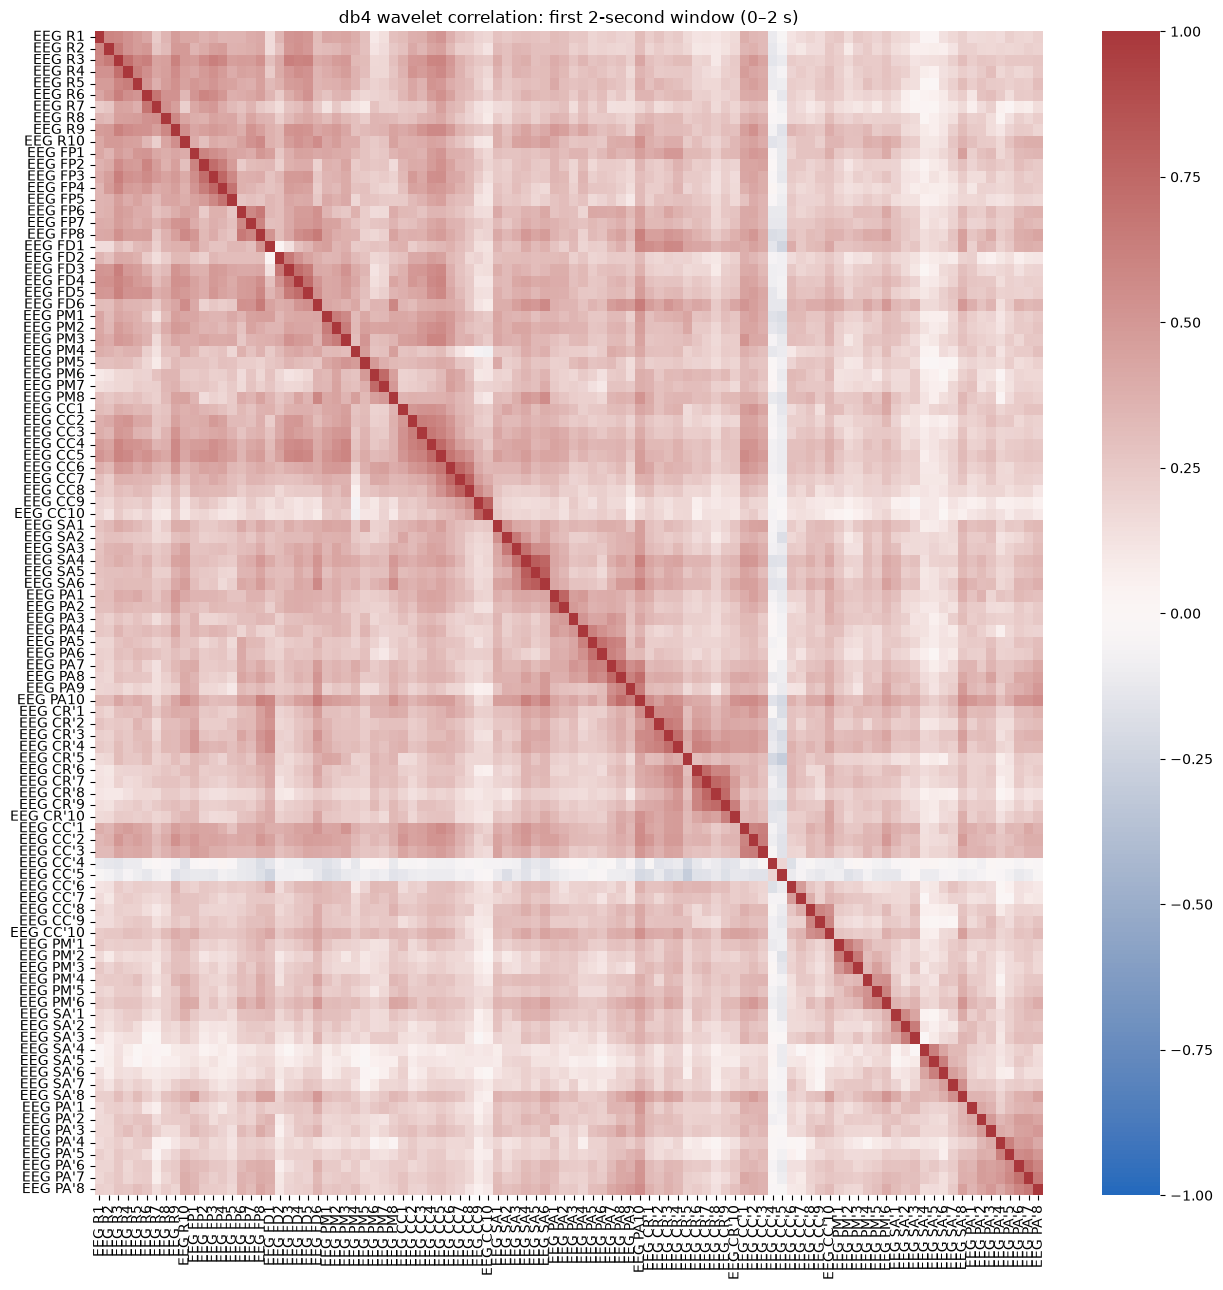

Saved: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/seeg_graph_output/first_2s_wavelet_correlation.pt


In [10]:
first_heatmap_tensor = torch.from_numpy(first_correlation).to(torch.float32)
torch.save(first_heatmap_tensor, OUTPUT_DIR / "first_2s_wavelet_correlation.pt")

plt.figure(figsize=(13, 13))
sns.heatmap(
    first_heatmap_tensor.numpy(), cmap="vlag", center=0, vmin=-1, vmax=1,
    xticklabels=seeg_channels, yticklabels=seeg_channels,
)
plt.title("db4 wavelet correlation: first 2-second window (0–2 s)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "first_2s_wavelet_correlation_heatmap.png", dpi=180)
plt.show()
print("Saved:", OUTPUT_DIR / "first_2s_wavelet_correlation.pt")


## Explicitly inspect the EDF-annotated event at 10396–10398 seconds

The temporal graph labels window 5198 as `known_extreme_event=True`; the three specified nodes carry `known_event_channel=True`. The plots below compare the event correlation matrix with the first window and highlight the three channels in the NetworkX graph. These labels **annotate** the known event but never change node measurements or edge weights.


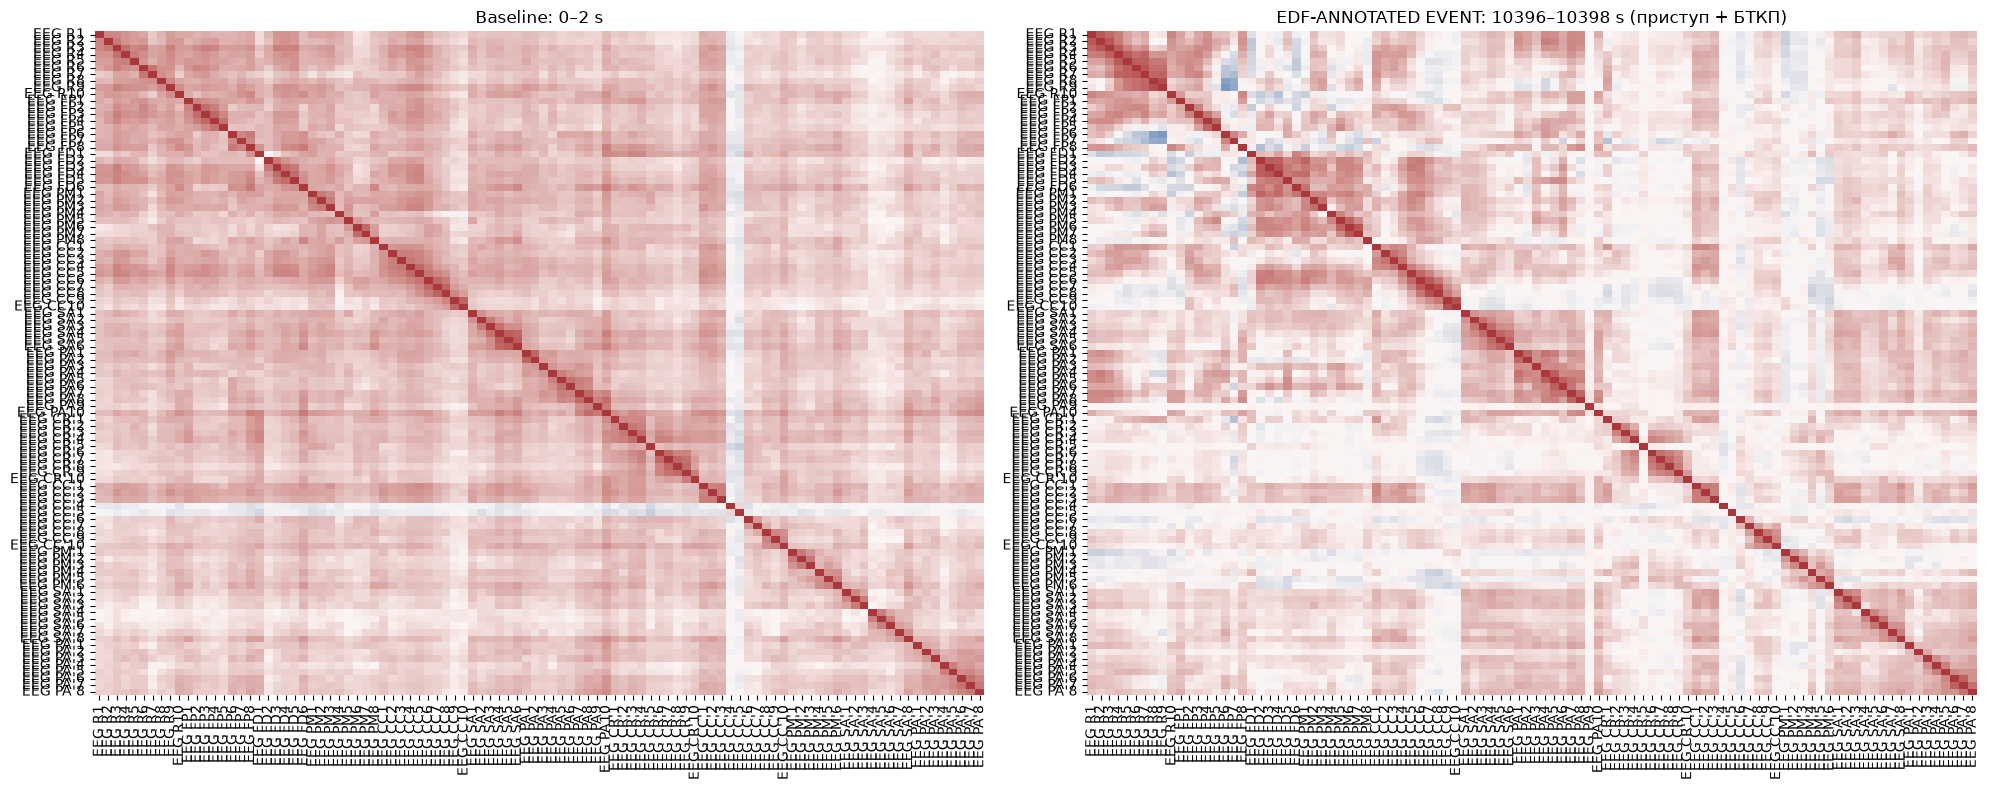

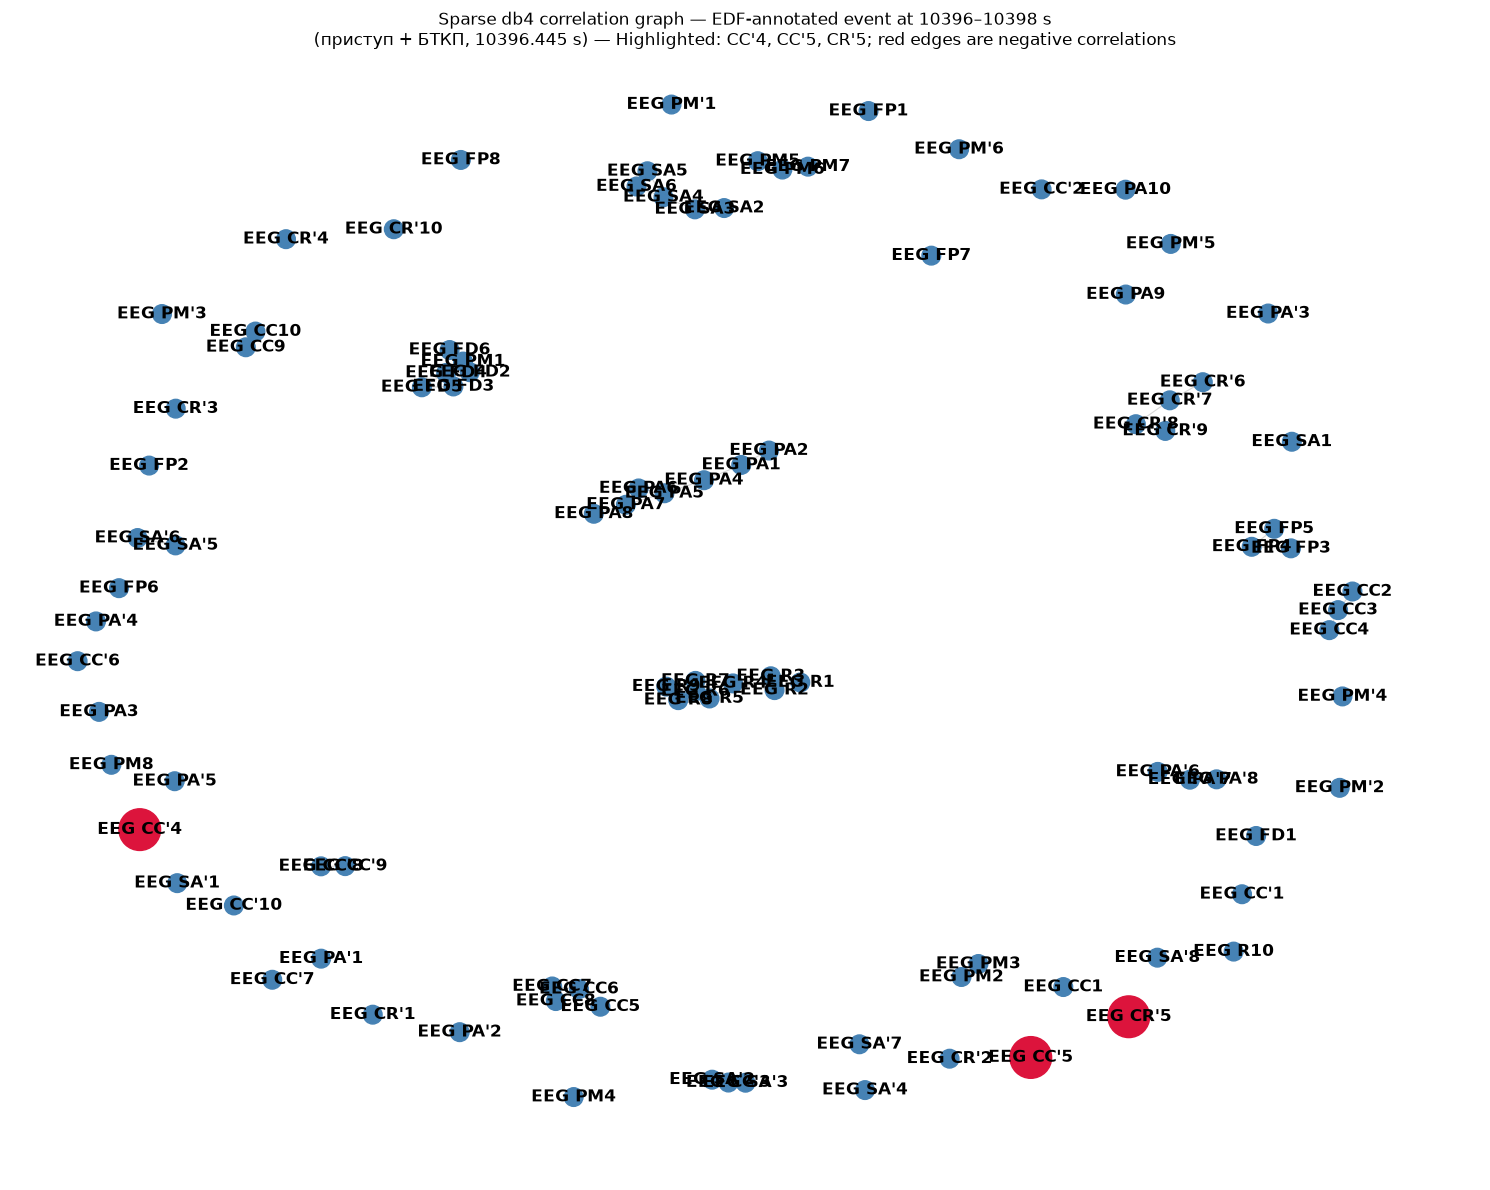

In [11]:
if event_graph is None:
    raise RuntimeError("The EDF-annotated event graph was not captured.")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, matrix, title in [
    (axes[0], first_correlation, "Baseline: 0–2 s"),
    (axes[1], event_correlation, "EDF-ANNOTATED EVENT: 10396–10398 s (приступ + БТКП)"),
]:
    sns.heatmap(matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
                xticklabels=seeg_channels, yticklabels=seeg_channels, ax=ax, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_vs_10396_10398_heatmaps.png", dpi=180)
plt.show()

present_event_channels = [name for name in KNOWN_EVENT_CHANNELS if name in event_graph]
node_colors = ["crimson" if name in present_event_channels else "steelblue" for name in event_graph.nodes]
node_sizes = [900 if name in present_event_channels else 180 for name in event_graph.nodes]
edge_colors = ["firebrick" if data["correlation"] < 0 else "0.65"
               for _, _, data in event_graph.edges(data=True)]
pos = nx.spring_layout(event_graph, seed=7, weight="abs_correlation")
plt.figure(figsize=(15, 12))
nx.draw_networkx_edges(event_graph, pos, edge_color=edge_colors, alpha=0.45, width=0.8)
nx.draw_networkx_nodes(event_graph, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(event_graph, pos,
                        labels={name: name for name in event_graph.nodes}, # Modified: Label all nodes
                        font_weight="bold", font_color="black")
plt.title("Sparse db4 correlation graph — EDF-annotated event at 10396–10398 s\n"
          "(приступ + БТКП, 10396.445 s) — "
          "Highlighted: CC'4, CC'5, CR'5; red edges are negative correlations")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "extreme_event_10396_10398_graph.png", dpi=180)
plt.show()

## Compare the known-event graph across montages

The same `build_window_graph` used for the whole recording above, called once more on the identical `10396–10398` s window but fed bipolar-derived data from `load_bipolar_window` instead of the referential channels — no separate graph-building logic, only a different input. This directly mirrors `extreme_event_agent.edf_workflow.build_seizure_graph`'s co-activation mesh being built from bipolar z-scores in the installable package's `compare_montages`.


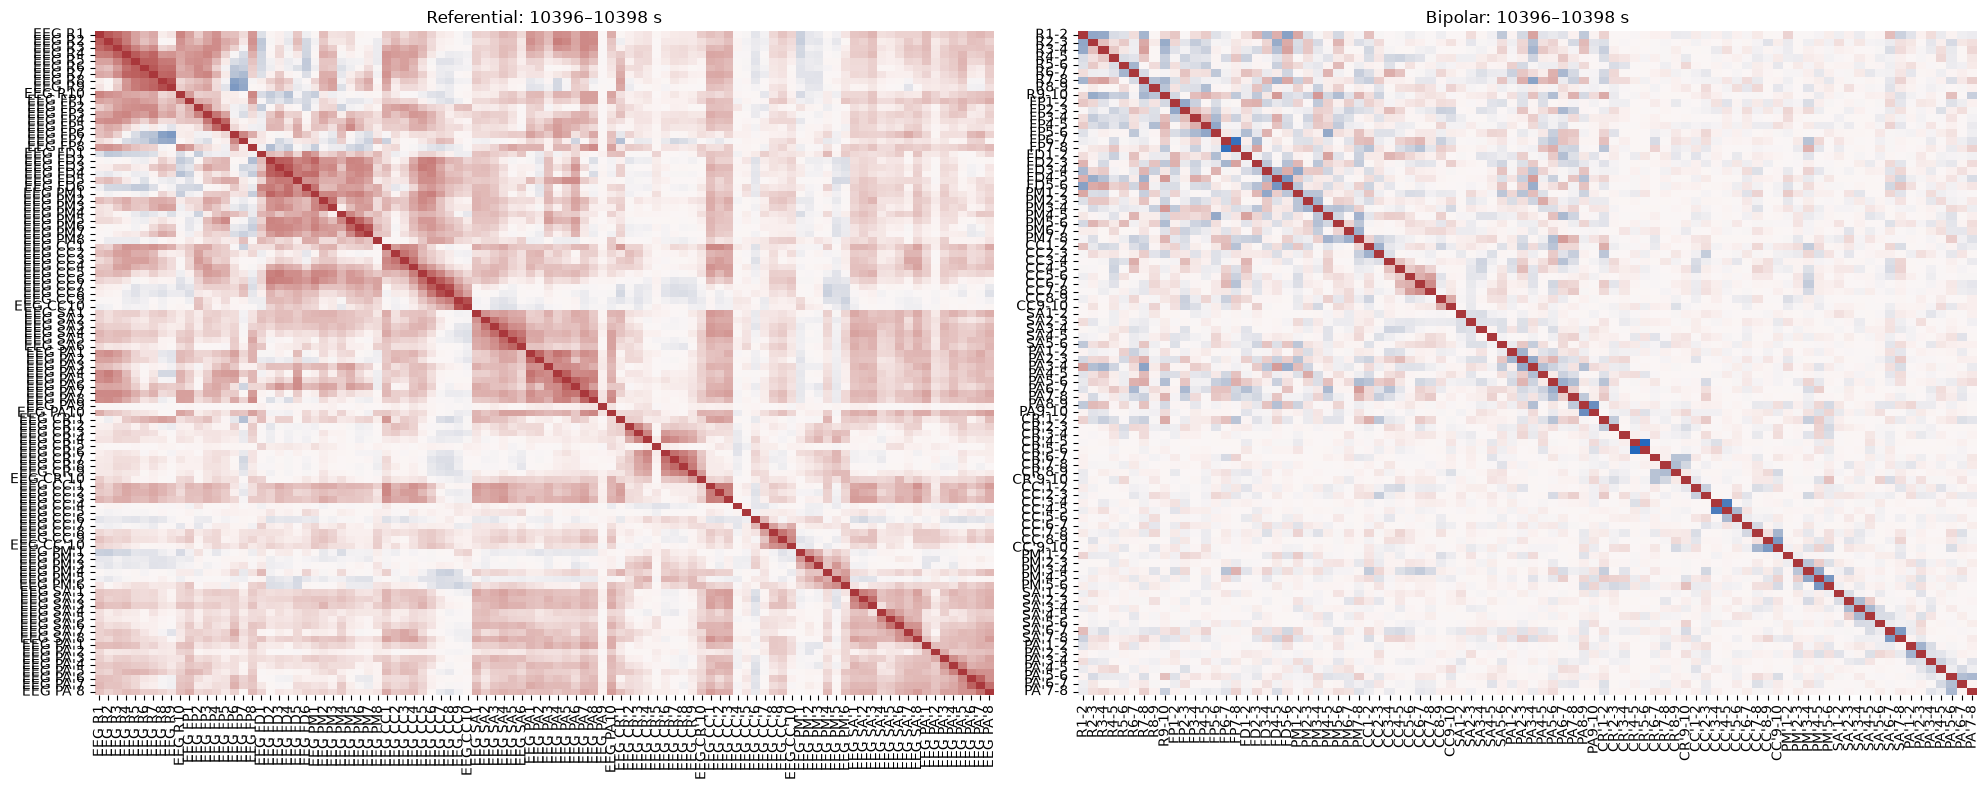

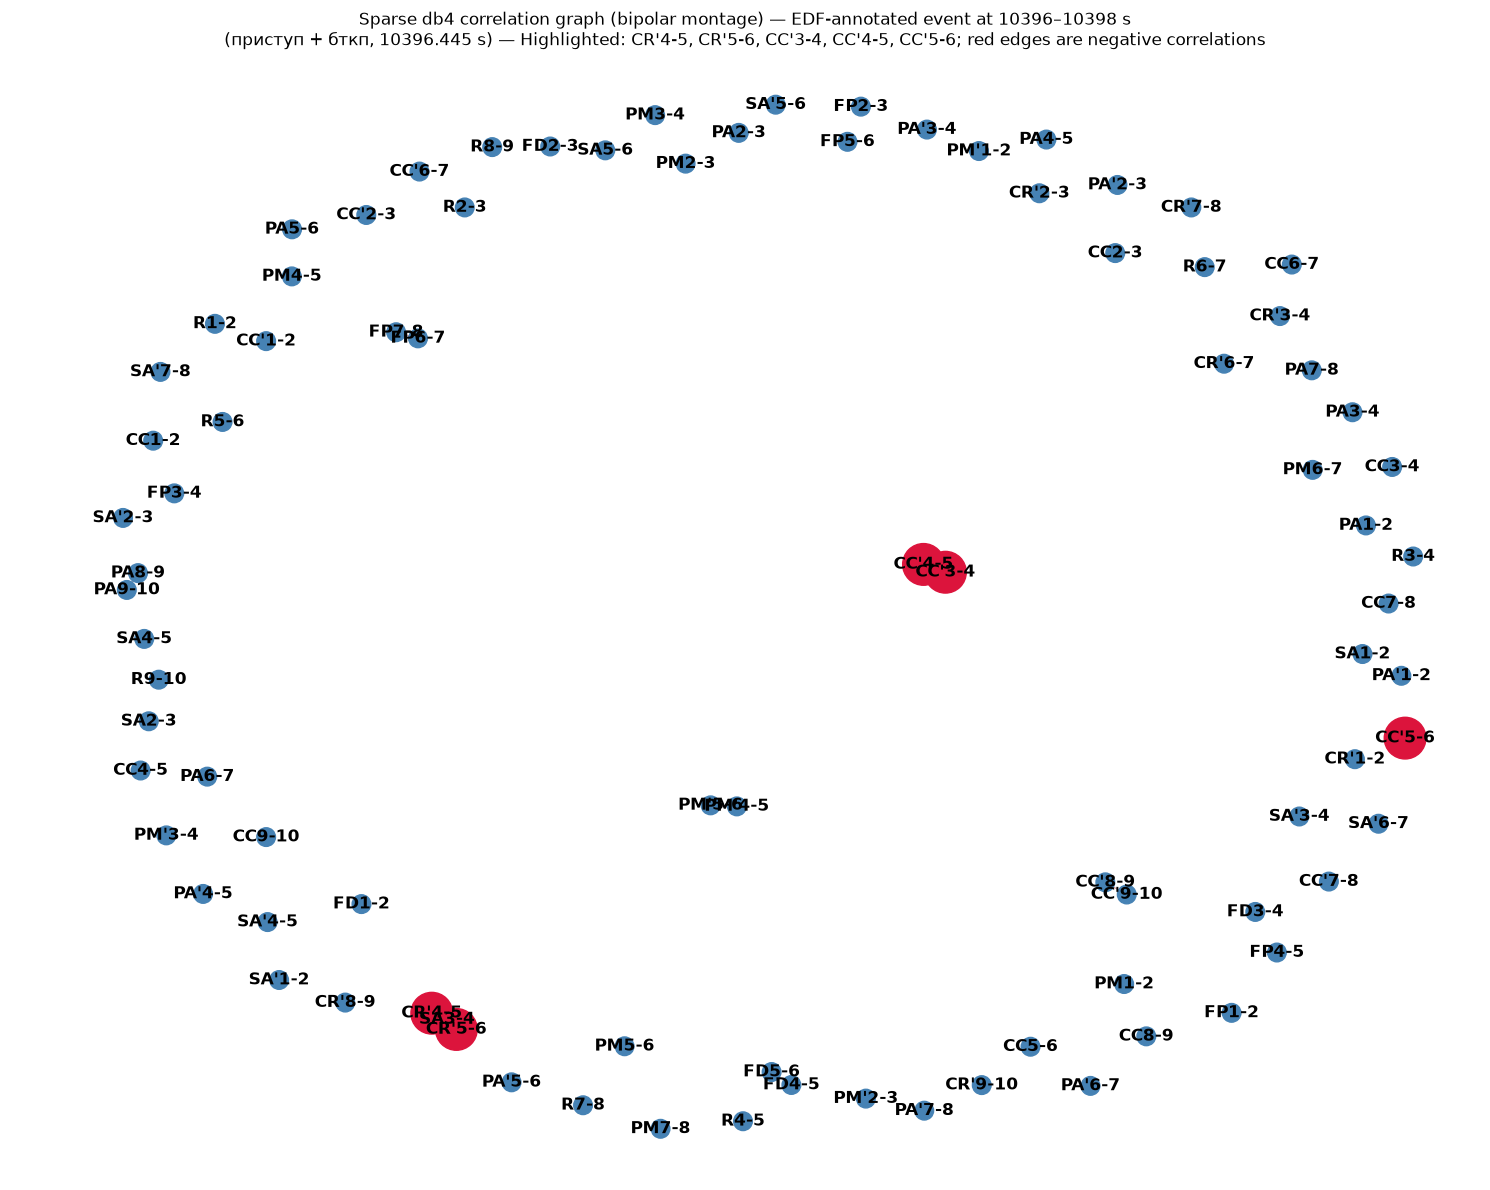

Montage comparison for the known-event window:
  referential: 100 nodes, 60 edges
  bipolar:     88 nodes, 7 edges


In [12]:
event_start_sample = int(round(KNOWN_EVENT_INTERVAL[0] * sfreq))
event_stop_sample = int(round(KNOWN_EVENT_INTERVAL[1] * sfreq))
bipolar_event_window_data = load_bipolar_window(event_start_sample, event_stop_sample)
bipolar_event_graph, bipolar_event_features, bipolar_event_correlation = build_window_graph(
    bipolar_event_window_data, bipolar_channels, KNOWN_EVENT_INTERVAL[0])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, matrix, channel_names, title in [
    (axes[0], event_correlation, seeg_channels, "Referential: 10396\u201310398 s"),
    (axes[1], bipolar_event_correlation, bipolar_channels, "Bipolar: 10396\u201310398 s"),
]:
    sns.heatmap(matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
                xticklabels=channel_names, yticklabels=channel_names, ax=ax, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "montage_comparison_10396_10398_heatmaps.png", dpi=180)
plt.show()

present_bipolar_event_channels = [name for name in bipolar_event_channels if name in bipolar_event_graph]
node_colors = ["crimson" if name in present_bipolar_event_channels else "steelblue"
              for name in bipolar_event_graph.nodes]
node_sizes = [900 if name in present_bipolar_event_channels else 180 for name in bipolar_event_graph.nodes]
edge_colors = ["firebrick" if data["correlation"] < 0 else "0.65"
              for _, _, data in bipolar_event_graph.edges(data=True)]
pos = nx.spring_layout(bipolar_event_graph, seed=7, weight="abs_correlation")
plt.figure(figsize=(15, 12))
nx.draw_networkx_edges(bipolar_event_graph, pos, edge_color=edge_colors, alpha=0.45, width=0.8)
nx.draw_networkx_nodes(bipolar_event_graph, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(bipolar_event_graph, pos,
                        labels={name: name for name in bipolar_event_graph.nodes},
                        font_weight="bold", font_color="black")
plt.title("Sparse db4 correlation graph (bipolar montage) \u2014 EDF-annotated event at "
          "10396\u201310398 s\n(\u043f\u0440\u0438\u0441\u0442\u0443\u043f + \u0431\u0442\u043a\u043f, 10396.445 s) \u2014 "
          f"Highlighted: {', '.join(bipolar_event_channels)}; red edges are negative correlations")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "montage_comparison_10396_10398_graph.png", dpi=180)
plt.show()

print("Montage comparison for the known-event window:")
print(f"  referential: {len(seeg_channels)} nodes, {event_graph.number_of_edges()} edges")
print(f"  bipolar:     {len(bipolar_channels)} nodes, {bipolar_event_graph.number_of_edges()} edges")


## Quantify and preserve the extreme point

The event-score trace is derived from the data: it averages the detail-band log-energy features of the three known channels. A red marker makes the 10396–10398 s EDF-annotated window structurally explicit even if another window happens to have a larger score. The printed percentile reports how extreme this known window is relative to the entire recording.


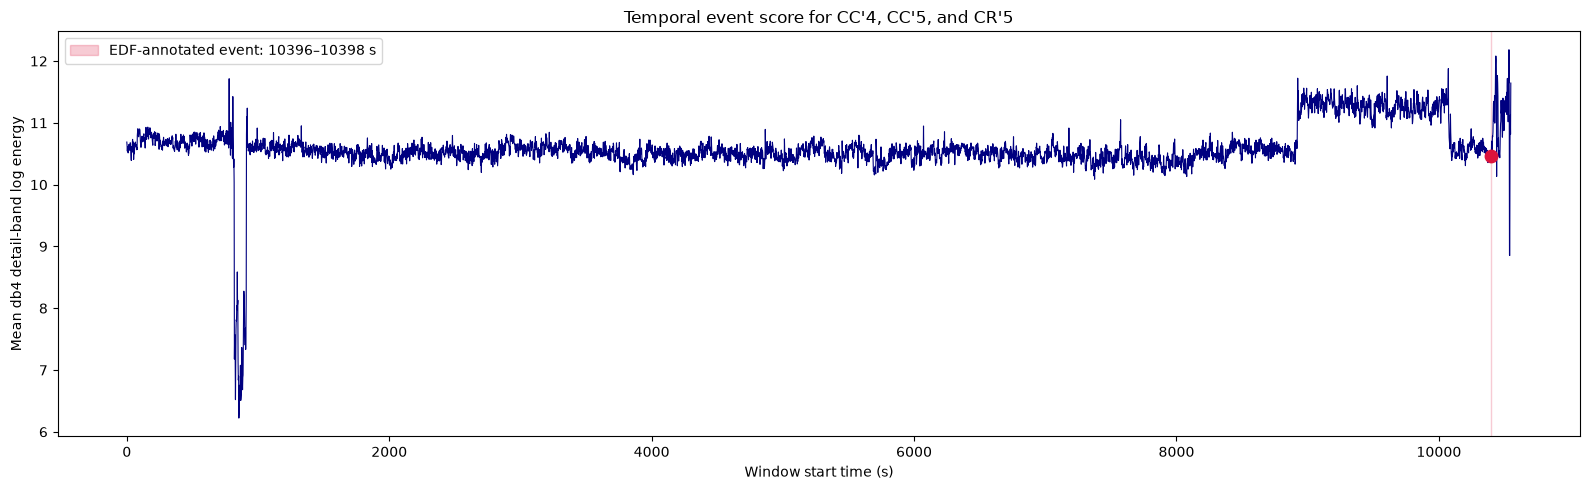

10396–10398 s event score: 10.4624 (percentile 27.68)


In [13]:
event_channel_indices = [seeg_channels.index(name) for name in KNOWN_EVENT_CHANNELS
                         if name in seeg_channels]
if not event_channel_indices:
    raise ValueError("None of the known event channels are present; cannot score the event.")

# Feature layout is [approximation energy, detail energies..., four statistics].
wavelet_energy_feature_count = node_features.shape[-1] - 4
detail_energy_slice = slice(1, wavelet_energy_feature_count)
event_score = node_features[:, event_channel_indices, detail_energy_slice].mean(dim=(1, 2))
known_score = event_score[event_window_index]
percentile = 100.0 * (event_score <= known_score).float().mean().item()

plt.figure(figsize=(16, 5))
plt.plot(window_start_seconds.numpy(), event_score.numpy(), linewidth=0.8, color="navy")
plt.axvspan(*KNOWN_EVENT_INTERVAL, color="crimson", alpha=0.22,
            label=f"EDF-annotated event: {KNOWN_EVENT_INTERVAL[0]:.0f}–{KNOWN_EVENT_INTERVAL[1]:.0f} s")
plt.scatter([KNOWN_EVENT_INTERVAL[0]], [known_score.item()], color="crimson", s=80, zorder=3)
plt.xlabel("Window start time (s)")
plt.ylabel("Mean db4 detail-band log energy")
plt.title("Temporal event score for CC'4, CC'5, and CR'5")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "known_event_score_timeline.png", dpi=180)
plt.show()
print(f"{KNOWN_EVENT_INTERVAL[0]:.0f}–{KNOWN_EVENT_INTERVAL[1]:.0f} s event score: "
      f"{known_score.item():.4f} (percentile {percentile:.2f})")


## Save the temporal graph tensors

`temporal_seeg_graph.pt` is directly loadable with `torch.load(..., weights_only=False)`. Node features are dense; each window's pruned adjacency is represented by `edge_index` and signed `edge_weight`. The metadata records channel order, feature names, pruning parameters, and the known extreme point. A separate event-only tensor makes the 10396–10398 s EDF-annotated graph easy to retrieve.


In [14]:
wavelet_level = first_graph.graph["wavelet_level"]
feature_names = (
    [f"log_energy_A{wavelet_level}"]
    + [f"log_energy_D{level}" for level in range(wavelet_level, 0, -1)]
    + ["mean_uV", "std_uV", "rms_uV", "line_length_uV"]
)

temporal_graph = {
    "node_features": node_features,
    "edge_index": edge_indices,
    "edge_weight": edge_weights,
    "window_start_seconds": window_start_seconds,
    "window_seconds": WINDOW_SECONDS,
    "channel_names": seeg_channels,
    "feature_names": feature_names,
    "sampling_frequency_hz": sfreq,
    "wavelet": WAVELET,
    "correlation_threshold": CORRELATION_THRESHOLD,
    "top_k_per_node": TOP_K_PER_NODE,
    "known_extreme_event": {
        "window_index": event_window_index,
        "interval_seconds": KNOWN_EVENT_INTERVAL,
        "channel_names": list(KNOWN_EVENT_CHANNELS),
        "event_score": known_score,
        "event_score_percentile": percentile,
    },
}
torch.save(temporal_graph, OUTPUT_DIR / "temporal_seeg_graph.pt")
torch.save({
    "node_features": node_features[event_window_index],
    "edge_index": edge_indices[event_window_index],
    "edge_weight": edge_weights[event_window_index],
    "full_correlation_heatmap": torch.from_numpy(event_correlation).float(),
    "channel_names": seeg_channels,
    "interval_seconds": KNOWN_EVENT_INTERVAL,
    "known_event_channels": list(KNOWN_EVENT_CHANNELS),
}, OUTPUT_DIR / "extreme_event_10396_10398_graph.pt")

print("Saved temporal graph:", OUTPUT_DIR / "temporal_seeg_graph.pt")
print("Saved extreme event graph:", OUTPUT_DIR / "extreme_event_10396_10398_graph.pt")
print("Output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)


Saved temporal graph: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/seeg_graph_output/temporal_seeg_graph.pt
Saved extreme event graph: /Users/denmacair/Documents/code_base/BioMedAI-sEEG-core-of-epilepsy/seeg_graph_output/extreme_event_10396_10398_graph.pt
Output files:
 - baseline_vs_10396_10398_heatmaps.png
 - extreme_event_10396_10398_graph.png
 - extreme_event_10396_10398_graph.pt
 - first_2s_wavelet_correlation.pt
 - first_2s_wavelet_correlation_heatmap.png
 - known_event_score_timeline.png
 - montage_comparison_10396_10398_graph.png
 - montage_comparison_10396_10398_heatmaps.png
 - temporal_seeg_graph.pt


## Reconstruct any window as a NetworkX graph

This helper converts a stored sparse tensor window back to NetworkX while preserving channel names and node feature vectors.


In [15]:
def tensor_window_to_networkx(saved, window_index):
    graph = nx.Graph(
        window_index=int(window_index),
        window_start_s=float(saved["window_start_seconds"][window_index]),
        known_extreme_event=(window_index == saved["known_extreme_event"]["window_index"]),
    )
    features = saved["node_features"][window_index]
    for index, name in enumerate(saved["channel_names"]):
        graph.add_node(name, index=index, features=features[index].numpy())
    # Edges were stored in both directions; add each undirected pair once.
    indices = saved["edge_index"][window_index]
    weights = saved["edge_weight"][window_index]
    for edge_position in range(indices.shape[1]):
        source, target = map(int, indices[:, edge_position])
        if source < target:
            graph.add_edge(
                saved["channel_names"][source], saved["channel_names"][target],
                correlation=float(weights[edge_position]),
            )
    return graph

loaded = torch.load(OUTPUT_DIR / "temporal_seeg_graph.pt", weights_only=False)
reconstructed_event_graph = tensor_window_to_networkx(loaded, loaded["known_extreme_event"]["window_index"])
print(reconstructed_event_graph)


Graph with 100 nodes and 60 edges


# Find biomarker

/var/folders/57/nnp0s5hs27d65fbf6n2frbjh0000gn/T/ipykernel_82304/288739197.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Correlation_with_Event_Score', data=correlation_df, palette='vlag', width=0.8)


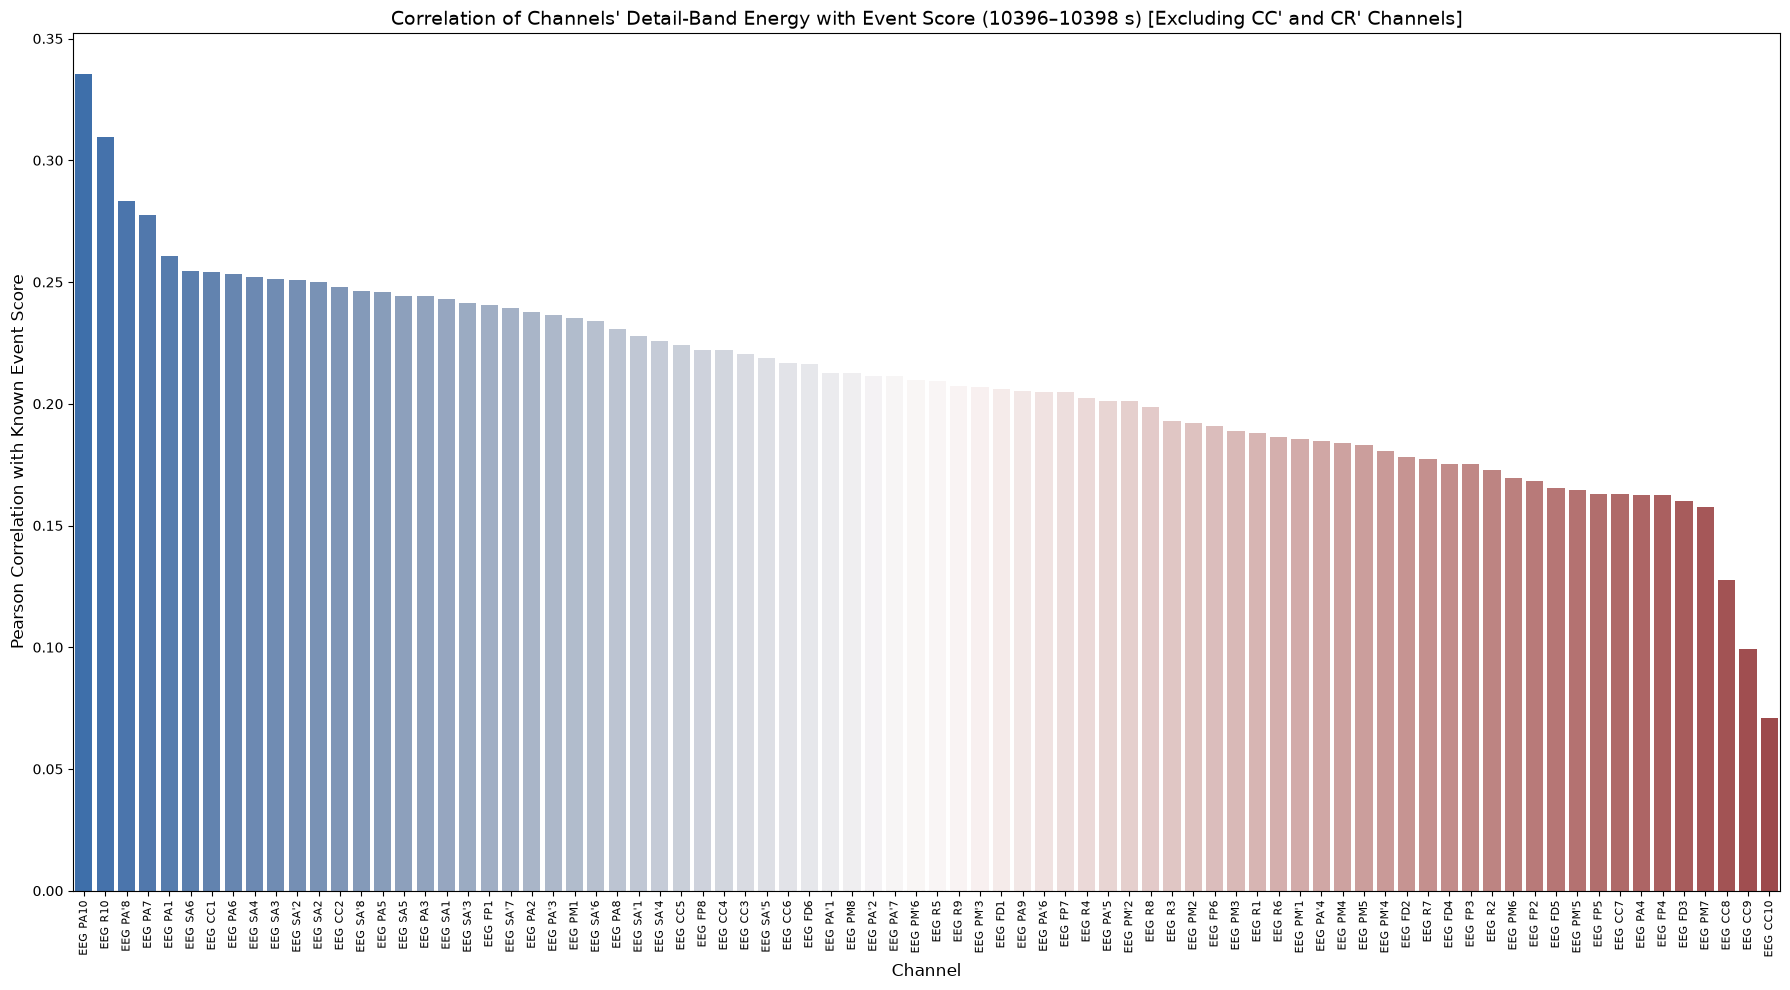


Top 10 channels positively correlated with the event score (excluding CC' and CR' channels):


,Channel,Correlation_with_Event_Score
57,EEG PA10,0.335466
9,EEG R10,0.309616
79,EEG PA'8,0.283276
54,EEG PA7,0.277684
48,EEG PA1,0.260852
47,EEG SA6,0.254652
32,EEG CC1,0.254276
53,EEG PA6,0.253245
45,EEG SA4,0.252250
44,EEG SA3,0.251142



Top 10 channels negatively correlated with the event score (excluding CC' and CR' channels):


,Channel,Correlation_with_Event_Score
62,EEG PM'5,0.164686
14,EEG FP5,0.163135
38,EEG CC7,0.162783
51,EEG PA4,0.162419
13,EEG FP4,0.162347
20,EEG FD3,0.160155
30,EEG PM7,0.157638
39,EEG CC8,0.127522
40,EEG CC9,0.099092
41,EEG CC10,0.071024


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Assuming node_features, event_score, seeg_channels, wavelet_energy_feature_count are available
# from previous cells.

# Define the slice for detail-band energy features, consistent with event_score calculation
# wavelet_energy_feature_count was 6, so detail_energy_slice is from index 1 to 5 (exclusive of 6)
detail_energy_slice = slice(1, wavelet_energy_feature_count)

# Dynamically identify channels to exclude based on the patterns CC'{i} and CR'{i}
exclude_pattern = re.compile(r"^EEG (CC|CR)'\d+$", flags=re.IGNORECASE)
channels_to_exclude_from_correlation = [
    ch for ch in seeg_channels if exclude_pattern.fullmatch(ch.strip())
]

# Calculate correlations for all channels with the known event score
correlations_with_event_score = {}
for i, channel_name in enumerate(seeg_channels):
    # Exclude channels matching the CC'{i} and CR'{i} patterns from this correlation evaluation
    if channel_name in channels_to_exclude_from_correlation:
        continue

    # Extract the mean detail-band log energy for the current channel across all windows
    # node_features has shape [window, channel, feature]
    channel_detail_energy_series = node_features[:, i, detail_energy_slice].mean(dim=1)

    # Calculate Pearson correlation
    # Convert to numpy for np.corrcoef and ensure both series are 1D
    correlation = np.corrcoef(channel_detail_energy_series.numpy(), event_score.numpy())[0, 1]
    correlations_with_event_score[channel_name] = correlation

# Convert to DataFrame for easier plotting and analysis
correlation_df = pd.DataFrame(
    list(correlations_with_event_score.items()),
    columns=['Channel', 'Correlation_with_Event_Score']
)

# Sort by correlation for better visualization
correlation_df = correlation_df.sort_values(by='Correlation_with_Event_Score', ascending=False)

# Visualize the correlations
plt.figure(figsize=(18, 10))
sns.barplot(x='Channel', y='Correlation_with_Event_Score', data=correlation_df, palette='vlag', width=0.8)
plt.xticks(rotation=90, fontsize=8) # Rotate labels for readability
plt.yticks(fontsize=10)
plt.xlabel("Channel", fontsize=12)
plt.ylabel("Pearson Correlation with Known Event Score", fontsize=12)
plt.title(f"Correlation of Channels' Detail-Band Energy with Event Score "
          f"({KNOWN_EVENT_INTERVAL[0]:.0f}–{KNOWN_EVENT_INTERVAL[1]:.0f} s) "
          "[Excluding CC' and CR' Channels]", fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.tight_layout()
plt.show()

# Display the top and bottom correlated channels
print("\nTop 10 channels positively correlated with the event score (excluding CC' and CR' channels):")
display(correlation_df.head(10))
print("\nTop 10 channels negatively correlated with the event score (excluding CC' and CR' channels):")
display(correlation_df.tail(10))

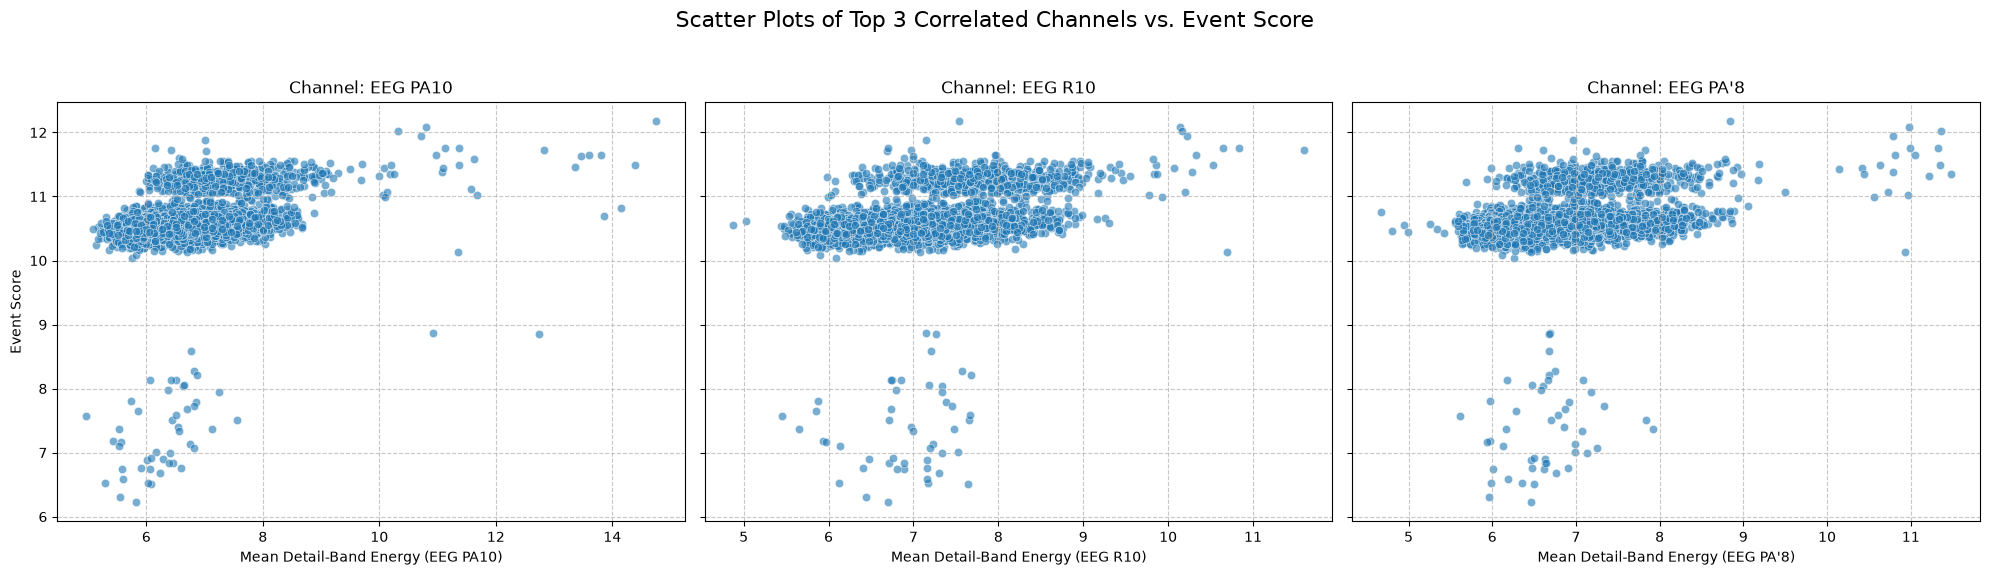

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 3 positively correlated channels
top_3_channels = correlation_df.head(3)['Channel'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Scatter Plots of Top 3 Correlated Channels vs. Event Score', fontsize=16)

for i, channel_name in enumerate(top_3_channels):
    ax = axes[i]
    # Find the index of the channel in seeg_channels
    channel_idx = seeg_channels.index(channel_name)

    # Extract the mean detail-band log energy for the current channel across all windows
    channel_detail_energy_series = node_features[:, channel_idx, detail_energy_slice].mean(dim=1)

    sns.scatterplot(x=channel_detail_energy_series.numpy(), y=event_score.numpy(), ax=ax, alpha=0.6)
    ax.set_title(f'Channel: {channel_name}')
    ax.set_xlabel(f'Mean Detail-Band Energy ({channel_name})')
    if i == 0: # Only set ylabel for the first subplot to avoid redundancy with sharey=True
        ax.set_ylabel('Event Score')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()